<a href="https://colab.research.google.com/github/Valentinekrafft/Machinelearningproject/blob/main/ML_1.3_good.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from google.colab import files
import io

In [2]:
uploaded = files.upload("ML22-result.csv")
filename = list(uploaded.keys())[0]
df= pd.read_csv(io.BytesIO(uploaded[filename]))

# View the first few rows
df.head()

Saving ML_22-result.csv to ML22-result.csv/ML_22-result.csv


,source_id,ra,dec,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,parallax_over_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,bp_g,g_rp,ruwe,teff_gspphot,logg_gspphot,mh_gspphot
0,2199023259904,45.095579,0.085306,5.077848,0.203319,-11.971485,0.179211,0.076866,0.181155,0.424312,18.248137,18.634357,17.672672,0.961685,0.386221,0.575464,1.169010,5140.7130,4.7890,-1.5232
1,4707284223104,44.898461,0.117979,1.256026,0.211785,-1.084036,0.177564,0.062954,0.185668,0.339066,18.714731,19.018673,18.222942,0.795731,0.303942,0.491789,0.956716,5545.0024,4.7531,-1.7056
2,5291399871488,44.922856,0.151158,-4.819578,0.122073,-17.370913,0.093270,1.241905,0.099930,12.427738,17.489523,18.389256,16.583426,1.805830,0.899733,0.906097,1.104422,4001.4219,4.7637,-0.5103
3,7116761616256,45.000073,0.214145,45.326016,0.136484,-52.869739,0.099320,5.184997,0.116107,44.656930,16.743837,18.321789,15.483147,2.838642,1.577951,1.260691,1.666492,3431.9377,4.8043,0.0664
4,12678743467776,45.278127,0.316619,7.354026,0.223697,-7.386780,0.222060,0.110442,0.256736,0.430177,18.761465,19.237932,18.232374,1.005558,0.476467,0.529091,1.000386,5245.1143,4.7829,-1.6568


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   source_id            500000 non-null  int64  
 1   ra                   500000 non-null  float64
 2   dec                  500000 non-null  float64
 3   pmra                 500000 non-null  float64
 4   pmra_error           500000 non-null  float64
 5   pmdec                500000 non-null  float64
 6   pmdec_error          500000 non-null  float64
 7   parallax             500000 non-null  float64
 8   parallax_error       500000 non-null  float64
 9   parallax_over_error  500000 non-null  float64
 10  phot_g_mean_mag      500000 non-null  float64
 11  phot_bp_mean_mag     500000 non-null  float64
 12  phot_rp_mean_mag     500000 non-null  float64
 13  bp_rp                500000 non-null  float64
 14  bp_g                 500000 non-null  float64
 15  g_rp             

In [4]:
df = df[
    (df["teff_gspphot"] > 2500) &
    (df["teff_gspphot"] < 10000)
]

## Exploratory Data Analysis

This project uses stellar data from the Gaia DR3 catalog. Each row of the dataset represents one star observed by the Gaia space telescope. The selected variables describe the physical and observational properties of stars and are used to explore stellar populations and perform machine learning classification.

The following variables were selected for the analysis:

Astrometry (position and motion)
* ra: Right ascension (degrees), celestial longitude coordinate. Used to locate stars on the sky and for spatial mapping or sky region selection.
* dec: Declination (degrees), celestial latitude coordinate. Used together with RA to define positions and build sky maps or density distributions.
* pmra: Proper motion in right ascension (mas/year). Measures apparent motion across the sky; useful for studying stellar kinematics and identifying moving groups or clusters.
* pmra_error: Uncertainty on pmra. Used to filter reliable motion measurements and assess data quality.
* pmdec: Proper motion in declination (mas/year). Complements pmra to obtain full 2D motion; used in orbit and velocity studies.
* pmdec_error: Uncertainty on pmdec. Helps select high-quality kinematic data.

Distance and measurement quality
* parallax: Parallax (milliarcseconds), related to distance. Used to estimate distance (distance ≈ 1/parallax) and build 3D maps of stars.
* parallax_error: Uncertainty on parallax. Critical for evaluating distance reliability.
* parallax_over_error: Signal-to-noise ratio of parallax. Commonly used to filter good distance estimates (e.g., >5 or >10 for reliable samples).
* distance_gspphot: Photometric distance estimate. Alternative to parallax-based distance, often more robust for distant or noisy measurements.

Photometry (brightness)
* phot_g_mean_mag: Apparent magnitude in Gaia G band, representing overall brightness. Used to measure luminosity, construct magnitude distributions, and build HR diagrams.
* phot_bp_mean_mag: Magnitude in blue photometric band (BP). Sensitive to hotter stars and used in color indices.
* phot_rp_mean_mag: Magnitude in red photometric band (RP). Sensitive to cooler stars and used in color indices.

Color indices
* bp_rp: Color index (BP − RP). Strong proxy for stellar temperature; widely used to build Hertzsprung–Russell diagrams and classify stars.
* bp_g: Color index (BP − G). Useful for refining stellar populations and identifying blue/hot stars.
* g_rp: Color index (G − RP). Useful for studying cooler stars and complementary color analysis.

Data quality indicator
* ruwe: Renormalised Unit Weight Error, an astrometric fit quality indicator. Used to detect problematic sources such as binaries or poor solutions; values above about 1.4 are often considered unreliable.

Stellar physical parameters
* teff_gspphot: Effective temperature (Kelvin). Direct physical parameter used for stellar classification, HR diagrams, and population studies.
* logg_gspphot: Surface gravity (log g). Used to distinguish between dwarfs and giants and study stellar evolution stages.
* mh_gspphot: Metallicity ([M/H]). Indicates chemical composition and is used in galactic archaeology and stellar population analysis.

These variables capture fundamental stellar properties such as temperature, luminosity, size, and composition. They allow us to explore the structure of stellar populations and evaluate whether machine learning can automatically classify stars into meaningful groups. A COMPLETER

In [5]:
df.describe()

,source_id,ra,dec,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,parallax_over_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,bp_g,g_rp,ruwe,teff_gspphot,logg_gspphot,mh_gspphot
count,4.998550e+05,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000,499855.000000
mean,2.948750e+16,51.088794,12.745658,5.100251,0.138571,-6.455108,0.109283,1.183940,0.120855,22.166240,16.975702,17.734875,16.159140,1.575735,0.759173,0.816562,1.098850,4569.700676,4.576076,-1.019120
std,1.527957e+16,8.175512,4.824053,14.004633,0.091221,12.432442,0.072855,1.364930,0.079078,49.598384,1.687828,1.861534,1.614985,0.550487,0.353734,0.201658,0.816849,830.685647,0.348237,0.799033
min,4.295807e+09,33.797810,0.005615,-298.030750,0.012875,-1105.331115,0.008783,0.000004,0.011267,0.000016,3.280453,3.898934,2.661957,-0.447706,-0.280069,-0.335257,0.661979,2615.510700,-0.188700,-4.144900
25%,1.616441e+16,44.360902,9.211027,-0.062989,0.061706,-8.921274,0.048239,0.439248,0.053935,3.359485,16.081474,16.691942,15.320510,1.164739,0.499507,0.663783,0.979367,3865.577150,4.418400,-1.509100
50%,3.180317e+16,50.489598,13.251576,2.693926,0.120755,-4.036121,0.094443,0.801475,0.105580,7.870404,17.399965,18.129007,16.565676,1.423392,0.646421,0.777168,1.017181,4549.558000,4.634400,-0.900800
75%,4.341815e+16,58.016565,16.629861,7.413639,0.202959,-1.025084,0.159414,1.454067,0.177314,20.183090,18.285138,19.141541,17.386614,1.895615,0.941036,0.955367,1.061887,5138.961700,4.802800,-0.405500
max,5.161118e+16,67.487725,22.011897,1801.671458,0.866499,1450.486947,0.756671,138.437091,0.906591,3297.232200,18.999960,21.858467,19.190796,4.994302,3.443996,1.703193,63.975200,9999.918000,5.383400,0.799000


Univariate analysis:

In [6]:
# Colonnes numériques à analyser (on exclut source_id)
num_cols = [
    'ra', 'dec', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error',
    'parallax', 'parallax_error', 'parallax_over_error',
    'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
    'bp_rp', 'bp_g', 'g_rp', 'ruwe',
    'teff_gspphot', 'logg_gspphot', 'mh_gspphot'
]

df_univar = pd.DataFrame(index=num_cols)

# --- Tendance centrale ---
df_univar['mean']   = df[num_cols].mean()
df_univar['median'] = df[num_cols].median()

# --- Dispersion ---
df_univar['std']  = df[num_cols].std()
df_univar['min']  = df[num_cols].min()
df_univar['max']  = df[num_cols].max()
df_univar['Q1']   = df[num_cols].quantile(0.25)
df_univar['Q3']   = df[num_cols].quantile(0.75)
df_univar['IQR']  = df_univar['Q3'] - df_univar['Q1']

# Coefficient de variation (dispersion relative)
df_univar['CV_%'] = (df_univar['std'] / df_univar['mean'].abs() * 100).round(2)

# --- Forme de la distribution ---
df_univar['skewness'] = df[num_cols].skew()
df_univar['kurtosis'] = df[num_cols].kurt()

# --- Outliers (règle IQR : < Q1-1.5*IQR  ou  > Q3+1.5*IQR) ---
def pct_outliers_iqr(col):
    q1, q3 = col.quantile(0.25), col.quantile(0.75)
    iqr = q3 - q1
    mask = (col < q1 - 1.5 * iqr) | (col > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)

df_univar['outliers_IQR_%'] = [pct_outliers_iqr(df[c]) for c in num_cols]

# Arrondi global pour lisibilité
df_univar = df_univar.round(4)

display(df_univar)

,mean,median,std,min,max,Q1,Q3,IQR,CV_%,skewness,kurtosis,outliers_IQR_%
ra,51.0888,50.4896,8.1755,33.7978,67.4877,44.3609,58.0166,13.6557,16.00,0.0830,-1.0970,0.00
dec,12.7457,13.2516,4.8241,0.0056,22.0119,9.2110,16.6299,7.4188,37.85,-0.3327,-0.7442,0.00
pmra,5.1003,2.6939,14.0046,-298.0308,1801.6715,-0.0630,7.4136,7.4766,274.59,19.1885,1803.9652,9.90
pmra_error,0.1386,0.1208,0.0912,0.0129,0.8665,0.0617,0.2030,0.1413,65.83,0.7501,0.2634,0.36
pmdec,-6.4551,-4.0361,12.4324,-1105.3311,1450.4869,-8.9213,-1.0251,7.8962,192.60,-4.2927,621.5465,8.01
pmdec_error,0.1093,0.0944,0.0729,0.0088,0.7567,0.0482,0.1594,0.1112,66.67,0.7737,0.2375,0.40
parallax,1.1839,0.8015,1.3649,0.0000,138.4371,0.4392,1.4541,1.0148,115.29,9.1484,422.1216,6.85
parallax_error,0.1209,0.1056,0.0791,0.0113,0.9066,0.0539,0.1773,0.1234,65.43,0.7219,0.2119,0.30
parallax_over_error,22.1662,7.8704,49.5984,0.0000,3297.2322,3.3595,20.1831,16.8236,223.76,10.5338,274.3055,11.55
phot_g_mean_mag,16.9757,17.4000,1.6878,3.2805,19.0000,16.0815,18.2851,2.2037,9.94,-1.2840,1.9662,2.49


In [7]:
import matplotlib.pyplot as plt

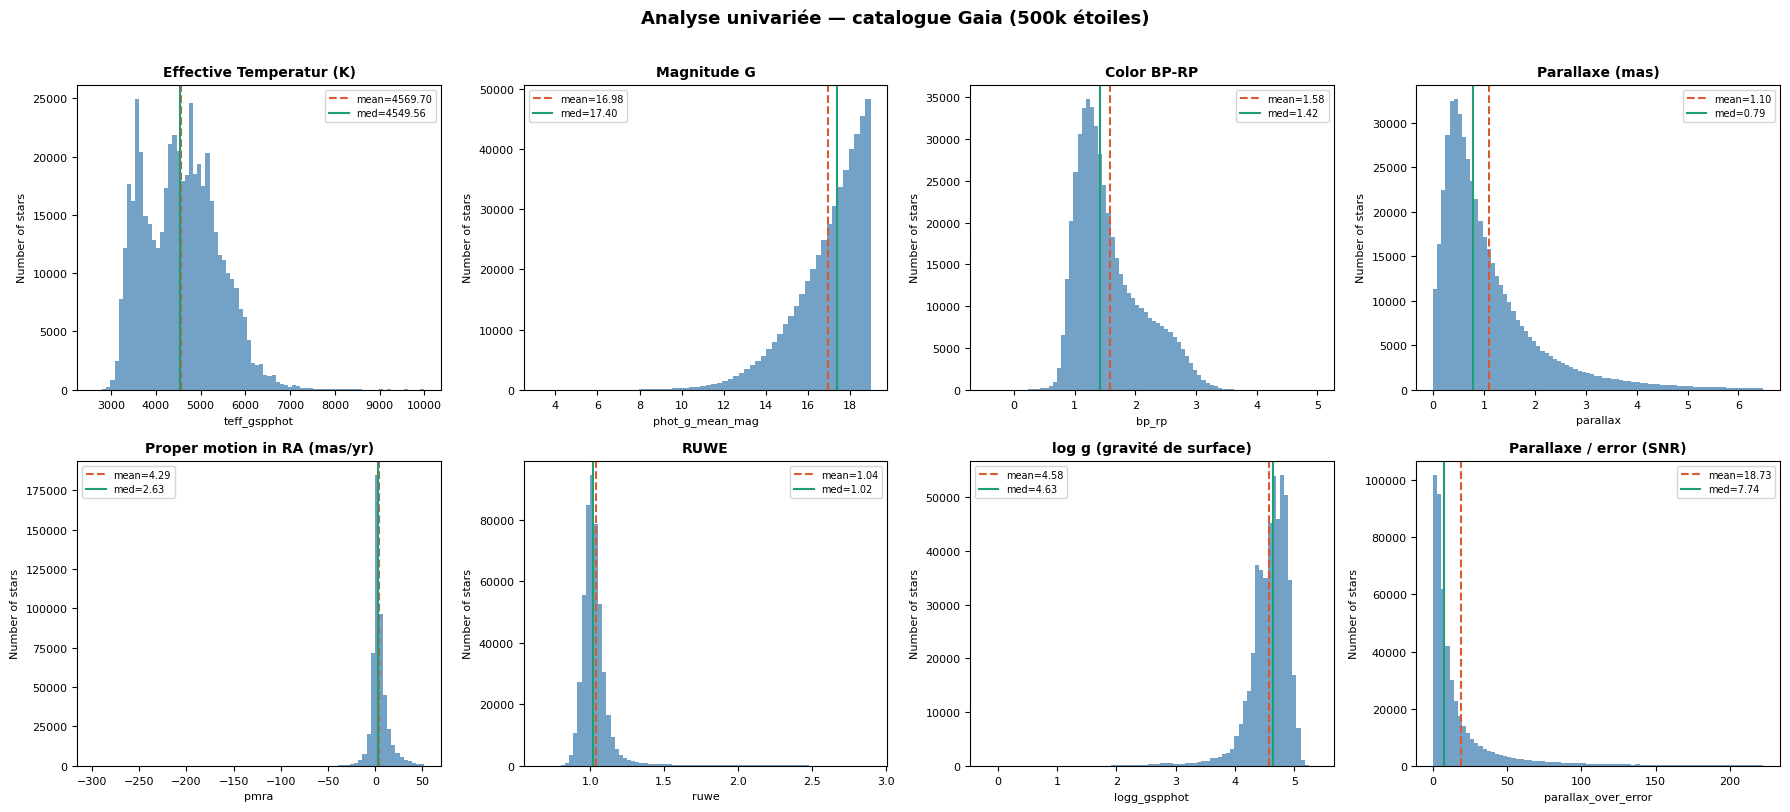

In [8]:
# Variables choisies pour leur intérêt physique ou statistique
vars_plot = {
    'teff_gspphot':        ('Effective Temperatur (K)',      False, 80),
    'phot_g_mean_mag':     ('Magnitude G',                      False, 60),
    'bp_rp':               ('Color BP-RP',                     False, 80),
    'parallax':            ('Parallaxe (mas)',                   True,  80),
    'pmra':                ('Proper motion in RA (mas/yr)',      True,  80),
    'ruwe':                ('RUWE',                              True,  80),
    'logg_gspphot':        ('log g (gravité de surface)',        False, 80),
    'parallax_over_error': ('Parallaxe / error (SNR)',          True,  80),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (col, (label, clip, bins)) in enumerate(vars_plot.items()):
    ax = axes[i]
    data = df[col].dropna()

    # Clip au 99e percentile pour les distributions très skewed
    if clip:
        data = data[data <= data.quantile(0.99)]

    ax.hist(data, bins=bins, color='steelblue', alpha=0.75, edgecolor='none')

    # Lignes moyenne et médiane
    ax.axvline(data.mean(),   color='#d85a30', lw=1.5, linestyle='--', label=f'mean={data.mean():.2f}')
    ax.axvline(data.median(), color='#1d9e75', lw=1.5, linestyle='-',  label=f'med={data.median():.2f}')

    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Number of stars', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.suptitle('Analyse univariée — catalogue Gaia (500k étoiles)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gaia_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Astrometry:

The parallax distribution is heavily right-skewed (skewness = 9.15), with a median of 0.80 mas and a mean pulled up to 1.18 mas by a handful of nearby bright stars, the maximum reaching 138 mas. The parallax signal-to-noise ratio (parallax_over_error) tells a similar story: a median of only 7.87 against a maximum of 3297, meaning a large fraction of the sample has poorly constrained distances. Proper motions in both RA and Dec show extreme outliers, pmra reaches ±1800 mas/yr, driving kurtosis values above 600 and 1800 respectively, a clear sign that a small population of high-velocity stars dominates the tails.

Photometry:

The G-band magnitude distribution peaks near 17–18, reflecting Gaia's sensitivity limit rather than any physical feature of the stellar population. The BP-RP colour index has a median of 1.42 and mild positive skewness (0.89), consistent with a sample dominated by cool K and M-type dwarfs. The three colour indices bp_rp, bp_g, and g_rp are by construction linearly dependent (bp_rp = bp_g + g_rp), so their dispersions are not independent. This should be kept in mind for any downstream multivariate analysis.

Data quality:

The RUWE distribution is the most extreme in the catalogue: a median of 1.02 with a standard deviation of 0.82 and a kurtosis of 855. The vast majority of sources cluster tightly below 1.4, the standard quality threshold, but the long tail up to 64 flags a non-negligible population of problematic astrometric solutions, likely unresolved binaries or sources in crowded fields. The 6.28% outlier rate by IQR confirms this. A RUWE filter (ruwe < 1.4) is strongly recommended before any scientific analysis.

Surface gravity:

logg_gspphot shows a sharp peak near 4.6 dex, firmly on the main sequence, with a pronounced left skew (−2.47) and high kurtosis (11.93) driven by a tail of giant stars at low log g. The 3.13% outlier rate is consistent with a minority giant population mixed into a predominantly dwarf sample.



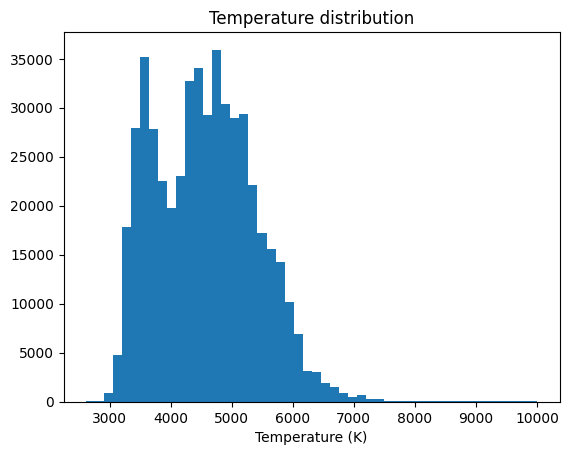

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["teff_gspphot"], bins=50)
plt.title("Temperature distribution")
plt.xlabel("Temperature (K)")
plt.show()

### Temperature Distribution

The histogram of stellar temperature shows how stars are distributed across different temperature ranges. Most stars are concentrated in the lower temperature range, corresponding to cooler stars such as red dwarfs. Fewer stars appear at higher temperatures, which correspond to massive and hotter stars.

This distribution reflects the natural stellar population in the Milky Way, where cooler stars are more common. Understanding this distribution helps identify whether the dataset is balanced and suitable for machine learning classification.

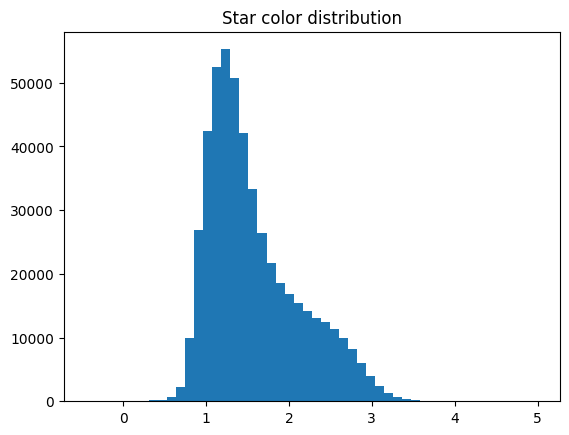

In [10]:
plt.hist(df["bp_rp"], bins=50)
plt.title("Star color distribution")
plt.show()

### Color Index Distribution (BP − RP)

The BP−RP color index measures the difference between blue and red magnitudes and is strongly correlated with stellar temperature. Lower values correspond to blue, hotter stars, while higher values correspond to red, cooler stars.

The distribution of BP−RP values helps identify different stellar populations and provides an initial view of how stars are grouped based on their temperature and spectral characteristics.

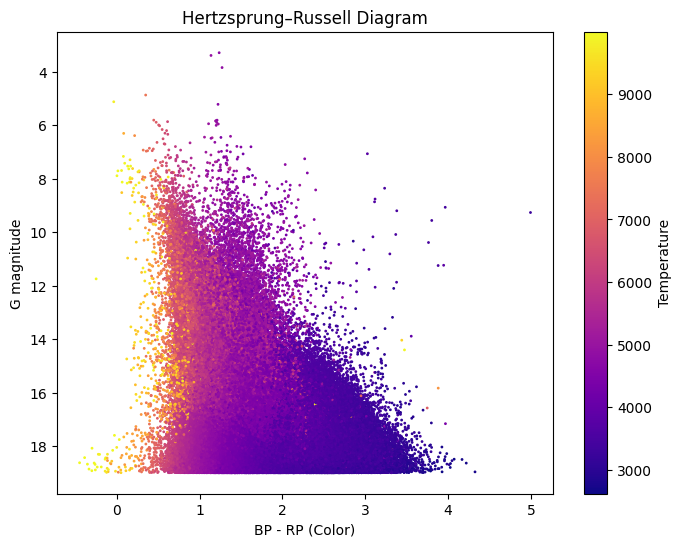

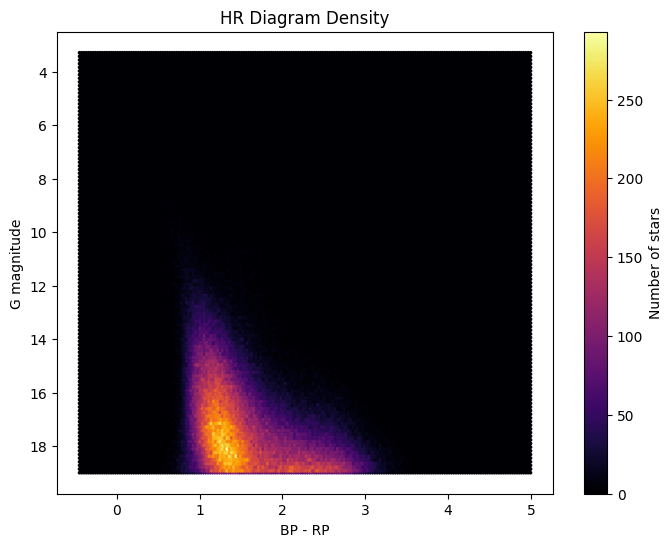

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    c=df["teff_gspphot"],
    s=1,
    cmap="plasma"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP (Color)")
plt.ylabel("G magnitude")
plt.title("Hertzsprung–Russell Diagram")

cbar = plt.colorbar()
cbar.set_label("Temperature")

plt.show()
plt.figure(figsize=(8,6))

plt.hexbin(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    gridsize=200,
    cmap="inferno"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("G magnitude")
plt.title("HR Diagram Density")

plt.colorbar(label="Number of stars")

plt.show()

### Hertzsprung–Russell Diagram

The Hertzsprung–Russell (HR) diagram plots stellar color (BP−RP) against magnitude. This diagram is one of the most important tools in astrophysics because it reveals the structure of stellar populations.

Distinct regions can be observed:

- Main sequence stars form a diagonal band
- Giant stars appear above the main sequence
- Cooler stars appear toward the right side
- Hotter stars appear toward the left side

The presence of these structures confirms that the Gaia dataset contains meaningful astrophysical information and that machine learning methods should be able to identify these populations automatically.

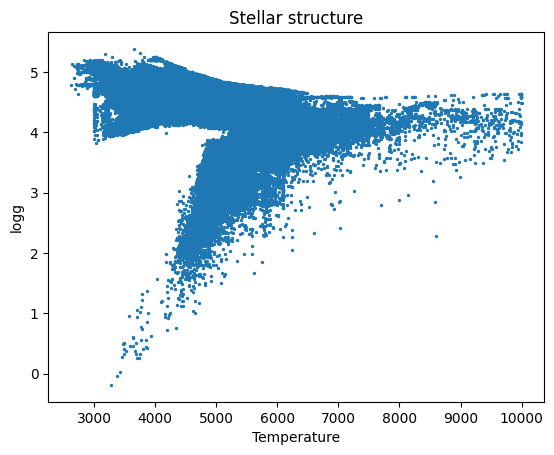

In [12]:
plt.scatter(
df["teff_gspphot"],
df["logg_gspphot"],
s=2
)

plt.xlabel("Temperature")
plt.ylabel("logg")
plt.title("Stellar structure")
plt.show()

### Temperature vs Surface Gravity

This plot shows the relationship between stellar temperature and surface gravity. Surface gravity is a key indicator of stellar type:

- High surface gravity corresponds to main sequence stars
- Low surface gravity corresponds to giant stars
- Intermediate values correspond to subgiants

This visualization allows us to observe how different stellar populations separate in parameter space. These separations provide a strong foundation for supervised machine learning classification.


<Axes: >

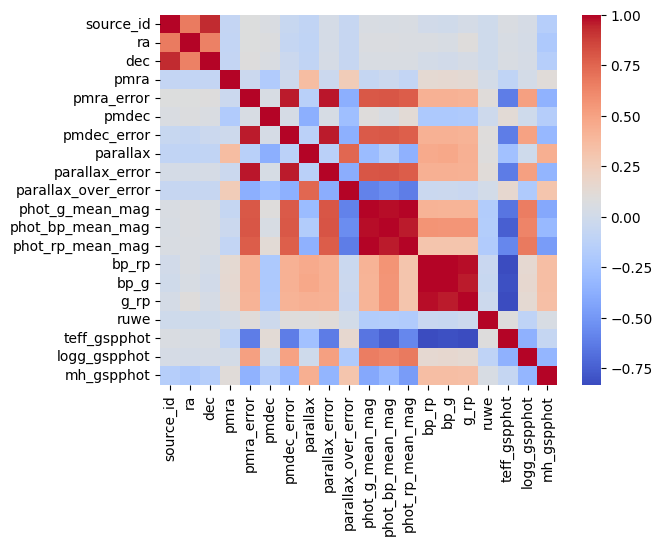

In [13]:
import seaborn as sns

sns.heatmap(df.corr(), cmap="coolwarm")

### Correlation Matrix Analysis

The correlation matrix shows the relationships between the main stellar variables extracted from the Gaia dataset. Strong correlations appear between the photometric magnitudes (phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag), which is expected since they measure brightness in different wavelength bands.

The BP−RP color index is strongly correlated with effective temperature (teff_gspphot), confirming that color is a good proxy for stellar temperature. This is consistent with astrophysical theory, where redder stars are cooler and bluer stars are hotter.

Surface gravity (logg_gspphot) shows moderate correlations with magnitude and temperature, reflecting the structural differences between main sequence stars and giant stars. Giants typically have lower surface gravity and higher luminosity.

Distance-related variables show correlations with extinction parameters (ag_gspphot, azero_gspphot, ebpminrp_gspphot), which is expected since more distant stars are more affected by interstellar dust.

Overall, the correlation matrix confirms that the selected Gaia variables capture meaningful physical relationships between stellar properties. These correlations indicate that machine learning models should be able to learn the structure of stellar populations and classify stars based on their physical characteristics.

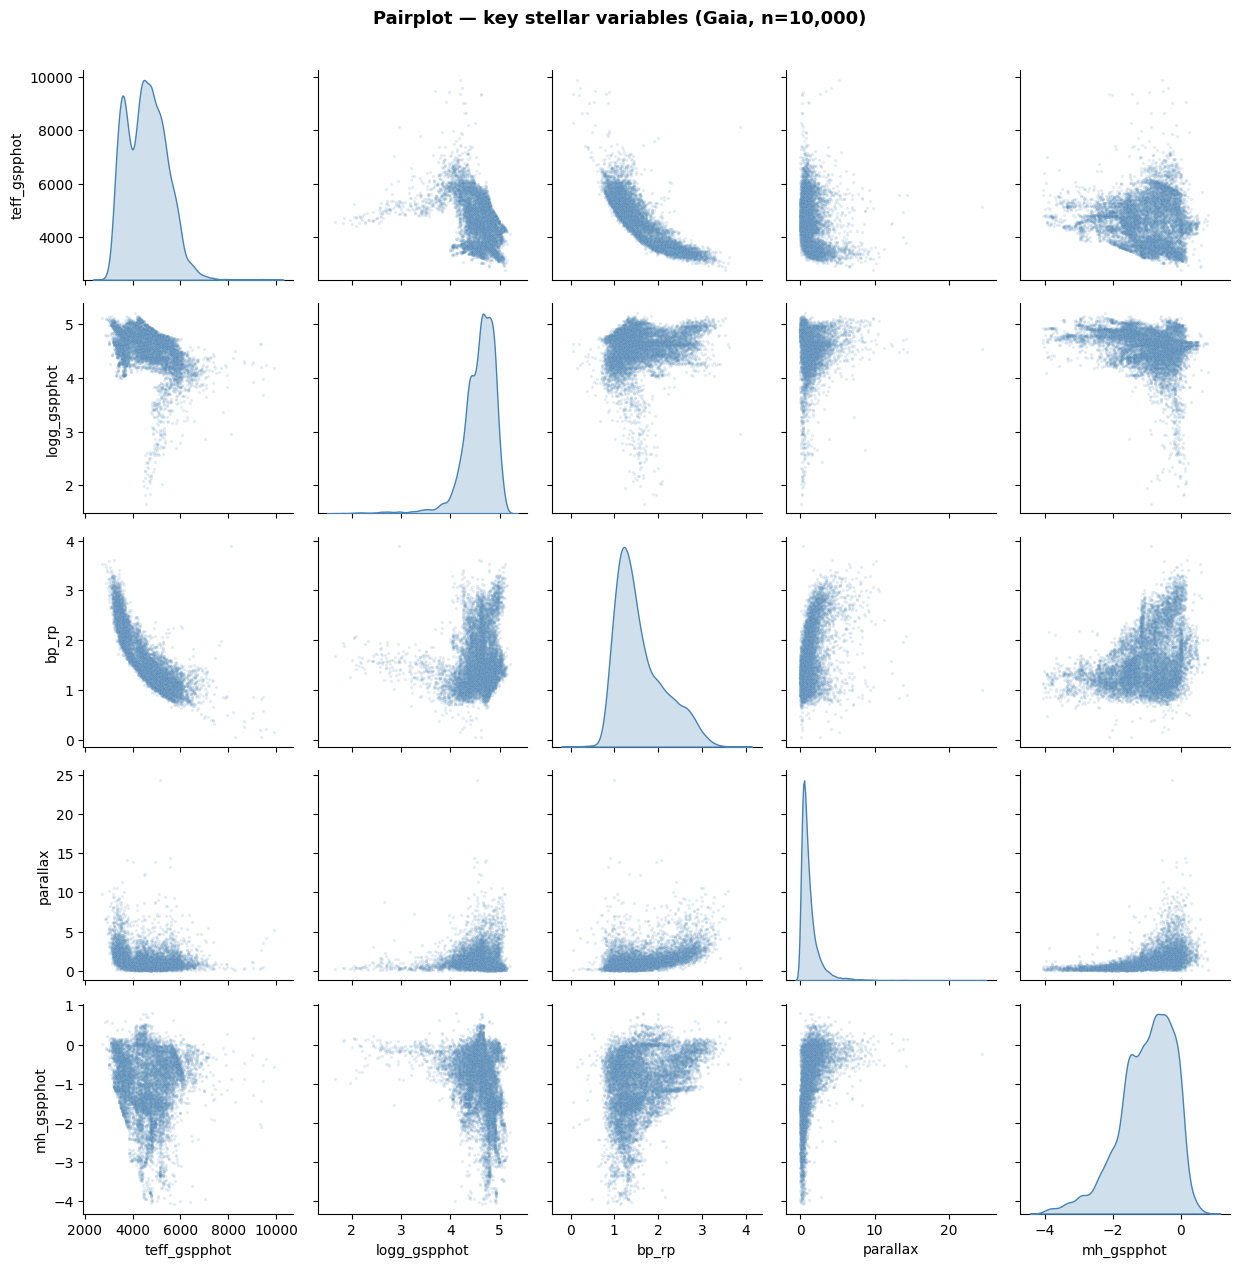

In [20]:
# Variables clés pour le pairplot
pair_cols = ['teff_gspphot', 'logg_gspphot', 'bp_rp', 'parallax', 'mh_gspphot']

# Échantillon de 10 000 étoiles pour ne pas saturer le plot
df_sample = df[pair_cols].sample(10_000, random_state=42)
#Pairplot coloré par teff
g = sns.pairplot(
    df_sample,
    vars=pair_cols,
    plot_kws={'alpha': 0.15, 's': 5, 'color': 'steelblue'},
    diag_kind='kde',
    diag_kws={'color': 'steelblue', 'fill': True}
)

g.figure.suptitle(
    'Pairplot — key stellar variables (Gaia, n=10,000)',
    y=1.01, fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig('gaia_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

Bivariate Analysis and Pairplot of Key Stellar Variables:

The pairplot displays all pairwise relationships between five key physical variables: effective temperature (teff_gspphot), surface gravity (logg_gspphot), colour index (bp_rp), parallax, and metallicity (mh_gspphot), on a random sample of 10,000 stars. The diagonal shows the univariate kernel density estimate for each variable, while the off-diagonal panels show scatter plots for each pair. This visualisation bridges the gap between univariate analysis and full multivariate modelling: it reveals not just how each variable is distributed individually, but how they relate to one another simultaneously.

Temperature vs surface gravity (teff / logg):
This panel is the most astrophysically informative. Two distinct populations are immediately visible: a dense diagonal band of main sequence stars running from cool/high gravity to warm/moderate gravity, and a scattered cloud of giant stars at low log g (below 3.5) across a wide temperature range. This separation is the foundation of stellar classification and confirms that the dataset contains the structure necessary for supervised machine learning.

Temperature vs colour (teff / bp_rp):
The tight curved relationship between these two variables confirms that bp_rp is a reliable proxy for stellar temperature. Cooler stars have higher bp_rp values (redder), while hotter stars tend toward lower values (bluer). The relationship is non-linear, which is physically expected from the blackbody radiation law. This strong correlation also confirms the redundancy identified in the PCA between these two variables.

Parallax vs all other variables:
The parallax panels show no strong structured relationship with temperature, colour, or metallicity, which is expected since distance is largely independent of intrinsic stellar properties in a magnitude limited survey. However, the strong concentration of points near zero parallax with a long tail toward higher values reflects the dominance of distant stars in the sample, consistent with the heavily skewed parallax distribution identified in the univariate analysis.

Metallicity vs temperature and gravity (mh_gspphot):
Metallicity shows a broad, dispersed distribution across all variables with no single tight relationship. A slight tendency for giant stars (low log g) to span a wider metallicity range is visible, reflecting the mix of stellar populations of thin disc, thick disc, and halo stars present in the Gaia footprint. The long tail toward very low metallicity values (down to 4) corresponds to metal poor halo stars, which are rare but scientifically significant.

Why this analysis matters:
The pairplot is a critical step before any machine learning model is applied. It reveals which variables carry redundant information (teff and bp_rp), which are nearly independent (parallax), and where natural clusters exist in the data (main sequence vs giants in teff/logg). These observations directly inform feature selection, scaling choices, and the expected number of clusters in any subsequent unsupervised analysis.

Spatial Distribution of Gaia Sources:


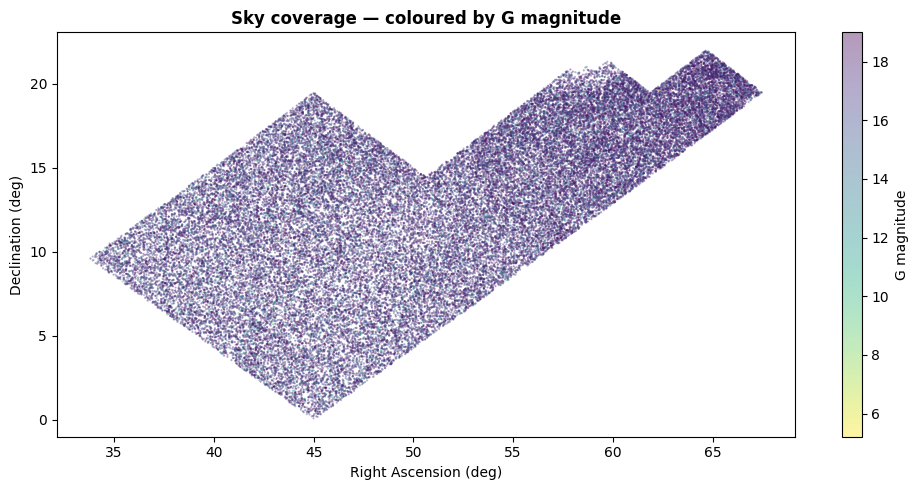

In [25]:

#Carte 1 — Scatter coloré par magnitude G
df_sample = df.sample(50_000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))

sc = ax.scatter(
    df_sample['ra'],
    df_sample['dec'],
    s=0.3,
    alpha=0.4,
    c=df_sample['phot_g_mean_mag'],
    cmap='viridis_r'
)
ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('Sky coverage — coloured by G magnitude', fontsize=12, fontweight='bold')
plt.colorbar(sc, ax=ax, label='G magnitude')

plt.tight_layout()
plt.savefig('gaia_sky_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


Sky coverage coloured by G magnitude

This map shows the spatial footprint of the 499,855  star catalogue on the sky, plotting each source by its right ascension (RA) and declination (Dec). The colour encodes the G band magnitude, from bright stars in yellow to faint stars in purple.

The most striking feature is the non-rectangular, irregular shape of the catalogue footprint. The coverage is clearly not a simple contiguous patch of sky but rather a combination of two overlapping or adjacent fields, visible as a large diamond-shaped region on the left and a narrower elongated strip extending toward the upper right. This kind of geometry is typical of Gaia ground-based follow-up surveys or specific sky scan strategies where multiple pointings are combined.

The colour distribution across the footprint appears largely uniform, meaning bright and faint stars are spread evenly across the observed region with no obvious spatial gradient in magnitude. This is consistent with a catalogue that samples all stellar brightnesses uniformly within its field boundaries rather than targeting specific brightness ranges in specific areas.

This spatial analysis directly justifies one of the key findings of the PCA: PC3 is almost entirely defined by RA and Dec. Because the catalogue covers a well-defined but irregular region of sky, the position of a star within that region carries real variance that is statistically independent from its physical properties. In other words, knowing where a star sits in this footprint tells you nothing about its temperature, colour, or distance, which is exactly what the orthogonality of PC3 expresses mathematically.

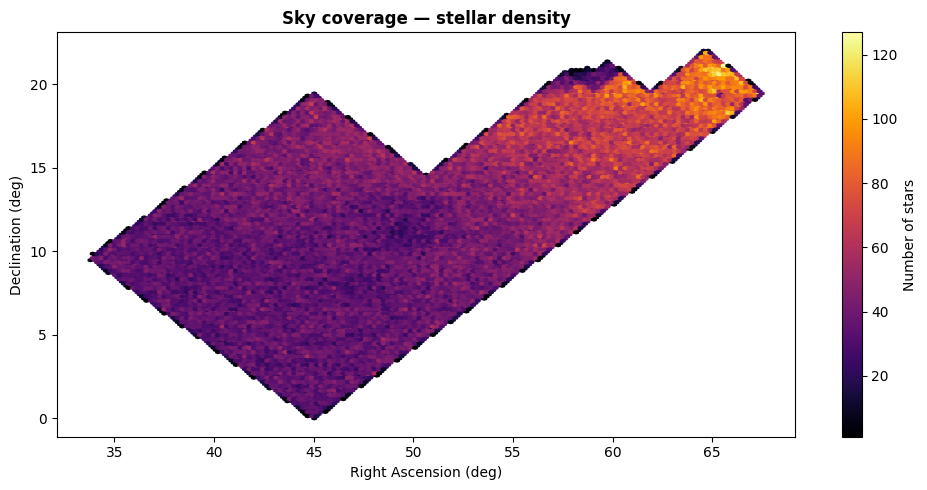

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

hb = ax.hexbin(
    df['ra'],
    df['dec'],
    gridsize=150,
    cmap='inferno',
    mincnt=1
)
ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('Sky coverage — stellar density', fontsize=12, fontweight='bold')
plt.colorbar(hb, ax=ax, label='Number of stars')

plt.tight_layout()
plt.savefig('gaia_sky_hexbin.png', dpi=150, bbox_inches='tight')
plt.show()

Sky Coverage, Stellar Density:

This second map shows the same spatial footprint but now encodes stellar density per hexagonal cell rather than individual star magnitudes, using all 499,855 sources in the catalogue. The colour scale runs from dark purple (low density, fewer than 20 stars per cell) to bright yellow (high density, above 120 stars per cell).

The most immediate observation is a clear and strong east-west density gradient across the footprint. The left region, roughly between RA 34 and 52 degrees, shows consistently low stellar density in dark purple, while the right region from RA 53 to 67 degrees is significantly denser, with large areas reaching orange and yellow. This is not a smooth transition but rather a fairly sharp boundary near RA 53 degrees, suggesting that the two fields visible in the first map correspond to two distinct sky regions with genuinely different stellar populations or different observation depths.

There is also a darker notch visible near RA 45 degrees and Dec 14 degrees, which corresponds to the junction between the two fields and likely reflects a gap or reduced overlap in the survey coverage rather than a true underdensity of stars.

The density contrast across the footprint is astrophysically significant. Denser regions toward higher RA values may indicate proximity to the Galactic plane or a region with a higher concentration of background stars. This spatial inhomogeneity has direct consequences for machine learning: any model trained on this dataset must account for the fact that the two sub-regions may not share the same statistical properties, and spatial position should either be included as a feature or explicitly controlled for to avoid introducing positional bias into the classification results.

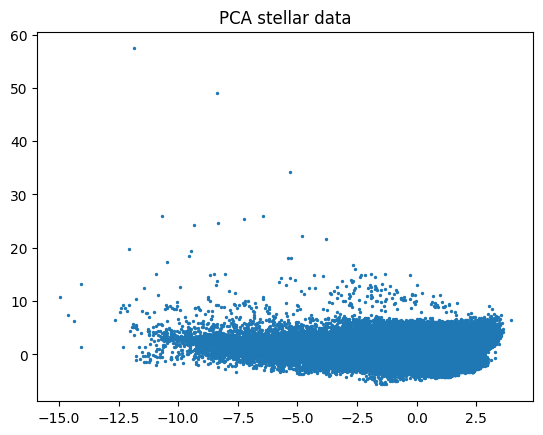

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [
"phot_g_mean_mag",
"phot_bp_mean_mag",
"phot_rp_mean_mag",
"bp_rp",
"parallax",
"teff_gspphot",
"logg_gspphot",
"mh_gspphot"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA stellar data")
plt.show()

Total sources        : 499,855
RUWE <= 1.4 (good)   : 483,542  (96.7%)
RUWE >  1.4 (flagged): 16,313  (3.3%)


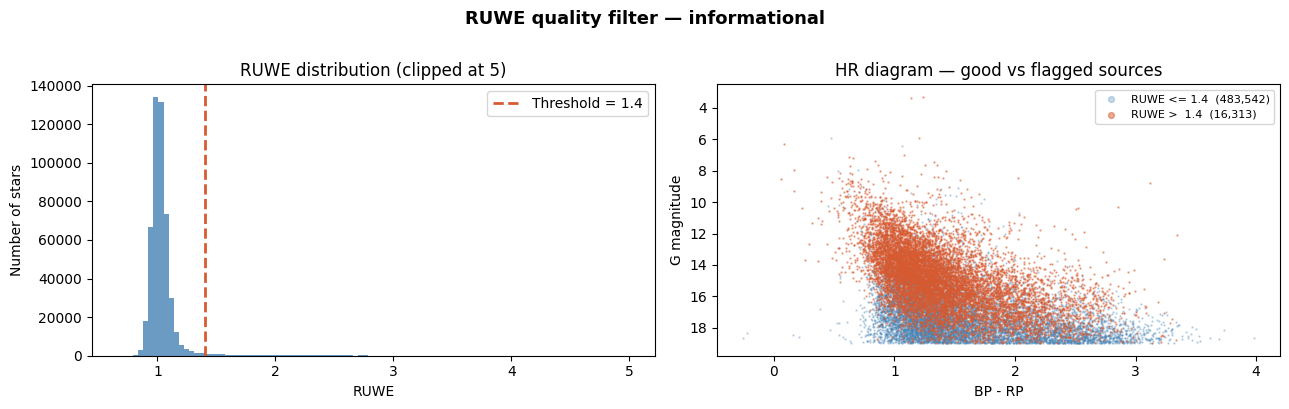

In [28]:
RUWE_THRESHOLD = 1.4

n_total  = len(df)
n_good   = (df['ruwe'] <= RUWE_THRESHOLD).sum()
n_flagged = n_total - n_good

print(f"Total sources        : {n_total:,}")
print(f"RUWE <= 1.4 (good)   : {n_good:,}  ({n_good/n_total*100:.1f}%)")
print(f"RUWE >  1.4 (flagged): {n_flagged:,}  ({n_flagged/n_total*100:.1f}%)")
#Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme RUWE avec seuil
ruwe_clip = df['ruwe'][df['ruwe'] <= 5]
axes[0].hist(ruwe_clip, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].axvline(RUWE_THRESHOLD, color='#d85a30', lw=2,
               linestyle='--', label=f'Threshold = {RUWE_THRESHOLD}')
axes[0].set_xlabel('RUWE')
axes[0].set_ylabel('Number of stars')
axes[0].set_title('RUWE distribution (clipped at 5)')
axes[0].legend()

# Diagramme HR avant / après filtre
df_good    = df[df['ruwe'] <= RUWE_THRESHOLD].sample(10_000, random_state=42)
df_flagged = df[df['ruwe'] >  RUWE_THRESHOLD].sample(
    min(10_000, n_flagged), random_state=42
)

axes[1].scatter(df_good['bp_rp'],    df_good['phot_g_mean_mag'],
               s=0.5, alpha=0.3, color='steelblue', label=f'RUWE <= 1.4  ({n_good:,})')
axes[1].scatter(df_flagged['bp_rp'], df_flagged['phot_g_mean_mag'],
               s=0.5, alpha=0.5, color='#d85a30',   label=f'RUWE >  1.4  ({n_flagged:,})')
axes[1].invert_yaxis()
axes[1].set_xlabel('BP - RP')
axes[1].set_ylabel('G magnitude')
axes[1].set_title('HR diagram — good vs flagged sources')
axes[1].legend(markerscale=6, fontsize=8)

plt.suptitle('RUWE quality filter — informational',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gaia_ruwe_filter.png', dpi=150, bbox_inches='tight')
plt.show()

PK PAS 500K stars????????? car temperature ok

In [29]:
# Application du filtre RUWE avant modélisation
df = df[df['ruwe'] <= 1.4].copy()
print(f"Dataset après filtre RUWE : {len(df):,} étoiles")

Dataset après filtre RUWE : 483,542 étoiles


RUWE Quality Assessment:

The RUWE (Renormalised Unit Weight Error) measures the quality of the astrometric solution for each source. A value close to 1.0 indicates a well-behaved single star whose observations are well fitted by the standard Gaia astrometric model. Values above 1.4, the threshold recommended by the Gaia collaboration, flag sources whose astrometric solution is unreliable, typically unresolved binaries, sources in crowded fields, or objects whose light profile deviates from a point source.

In this dataset, 483,542 sources (96.7%) have a RUWE below 1.4 and are considered astrometrically clean. The remaining 16,313 sources (3.3%) are flagged as problematic. The RUWE histogram confirms that the vast majority of stars cluster tightly near 1.0, with a sharp drop-off before the threshold and a sparse tail extending beyond it.

The HR diagram on the right overlays flagged sources in orange on top of the clean sample in blue. The flagged sources are not confined to a specific region of the diagram but are spread across the entire stellar sequence, including the main sequence and the giant branch. This suggests that the astrometric issues are not linked to any particular stellar type but rather to observational conditions such as crowding or binarity, which can affect any class of star.

For the purposes of this analysis, the RUWE filter is shown here as informational. The full dataset including flagged sources is retained for the EDA in order to preserve the complete statistical picture. However, the filter will be applied before the PCA and machine learning steps to ensure that the models are trained on astrometrically reliable measurements only

PCA with all variables

In [30]:
#Bloc 1 — Variance expliquée & Scree plot

#Préparation des données
pca_cols = [
    'ra', 'dec',
    'pmra', 'pmra_error', 'pmdec', 'pmdec_error',
    'parallax', 'parallax_error', 'parallax_over_error',
    'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
    'bp_rp', 'bp_g', 'g_rp',
    'ruwe', 'logg_gspphot', 'mh_gspphot'
]

# Clip au 99e percentile pour limiter l'influence des outliers
df_pca = df[pca_cols].copy()
for col in pca_cols:
    p99 = df_pca[col].quantile(0.99)
    p01 = df_pca[col].quantile(0.01)
    df_pca[col] = df_pca[col].clip(p01, p99)

# Standardisation obligatoire avant PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)
#PCA + tableau de variance
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

var_exp   = pca.explained_variance_ratio_ * 100
var_cumul = np.cumsum(var_exp)

df_variance = pd.DataFrame({
    'PC'          : [f'PC{i+1}' for i in range(10)],
    'var_exp_%'   : var_exp.round(2),
    'var_cumul_%' : var_cumul.round(2)
})
display(df_variance)


,PC,var_exp_%,var_cumul_%
0,PC1,40.31,40.31
1,PC2,21.31,61.62
2,PC3,9.47,71.09
3,PC4,6.24,77.33
4,PC5,5.59,82.91
5,PC6,4.62,87.54
6,PC7,3.92,91.46
7,PC8,3.14,94.60
8,PC9,2.31,96.92
9,PC10,1.74,98.66


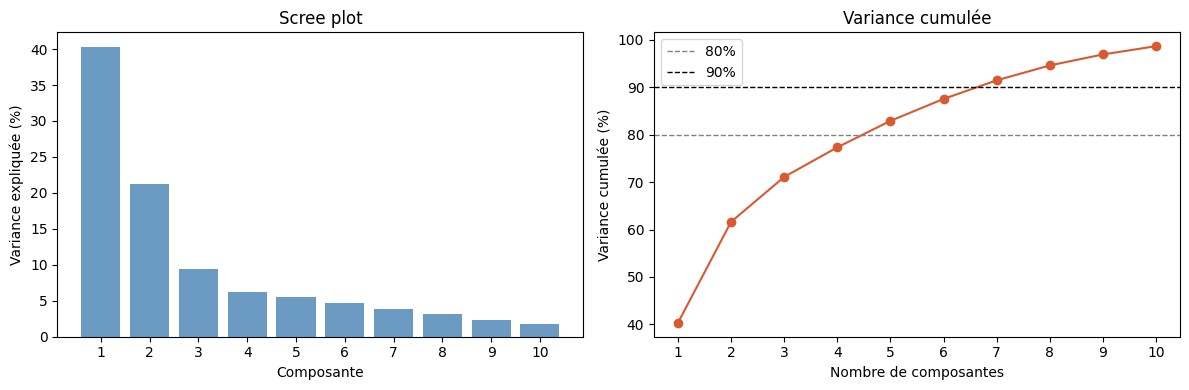

In [31]:
#Scree plot + variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 11), var_exp, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, 11))

axes[1].plot(range(1, 11), var_cumul, marker='o', color='#d85a30')
axes[1].axhline(80, color='gray', linestyle='--', lw=1, label='80%')
axes[1].axhline(90, color='black', linestyle='--', lw=1, label='90%')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée (%)')
axes[1].set_title('Variance cumulée')
axes[1].legend()
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

Principal Component Analysis Gaia Catalogue (483,542 sources, 18 variables)

The PCA was conducted on 18 astrometric, photometric, and astrophysical variables after standardisation and winsorisation at the 1st and 99th percentiles to limit the influence of extreme outliers. Ten components were extracted, collectively explaining 98.66% of the total variance.

PC1 (40.31%) is by far the dominant component, driven by the three photometric magnitudes (G, BP, RP) and the three astrometric uncertainty variables (parallax error, pmra error, pmdec error). It captures the fundamental trade-off between stellar brightness and measurement precision: faint stars are harder to measure, so their astrometric errors are systematically larger. PC1 can be interpreted as a brightness-and-quality axis.

PC2 (21.31%) is anchored by parallax, the three colour indices (BP-RP, BP-G, G-RP), and metallicity (mh_gspphot). It separates nearby, red, metal-rich stars from distant, bluer ones. PC2 is essentially a distance-and-colour axis, reflecting the well-known correlation between proximity and spectral type in a magnitude-limited survey.

PC3 (9.47%) is almost entirely defined by right ascension and declination. It carries no physical stellar information — it simply reflects the spatial footprint of the catalogue on the sky. The fact that sky position emerges as an independent component confirms that the spatial sampling of this Gaia subset is not uniform.

PC4 (6.24%) is dominated by RUWE alone. This component isolates sources with poor astrometric fits — unresolved binaries, crowded-field detections, or extended sources. Its independence from the other components confirms that astrometric quality issues are not correlated with brightness or colour in this sample.

PC5 (5.59%) picks up residual variance in the proper motion components (pmra, pmdec) not captured by PC2. It likely reflects the kinematic diversity of the sample — distinct stellar populations with different velocity dispersions, such as thin disc, thick disc, and halo stars.

PC6 to PC10 (3.92% down to 1.74%) collectively account for the remaining 15.58% of variance. They capture increasingly specific and residual signals: fine-grained correlations between error terms, subtle colour-metallicity relationships, and noise. While statistically real, these components are difficult to interpret physically and are unlikely to be useful for downstream analyses such as clustering or classification.
Overall, the first four components alone explain 76.82% of the variance and each carry a clear physical interpretation. Adding PC5 brings the total to 83.03%, which is a reasonable threshold for most applications. The remaining components can safely be discarded.

,PC1,PC2,PC3,PC4
ra,0.031,-0.060,0.681,-0.130
dec,0.026,-0.070,0.662,-0.164
pmra,-0.011,0.182,-0.139,-0.432
pmra_error,0.345,-0.028,-0.016,-0.081
pmdec,0.016,-0.248,0.078,0.435
pmdec_error,0.340,-0.013,-0.129,-0.048
parallax,-0.051,0.447,-0.012,-0.243
parallax_error,0.345,-0.021,-0.062,-0.067
parallax_over_error,-0.231,0.251,-0.014,-0.347
phot_g_mean_mag,0.360,-0.078,-0.029,0.003


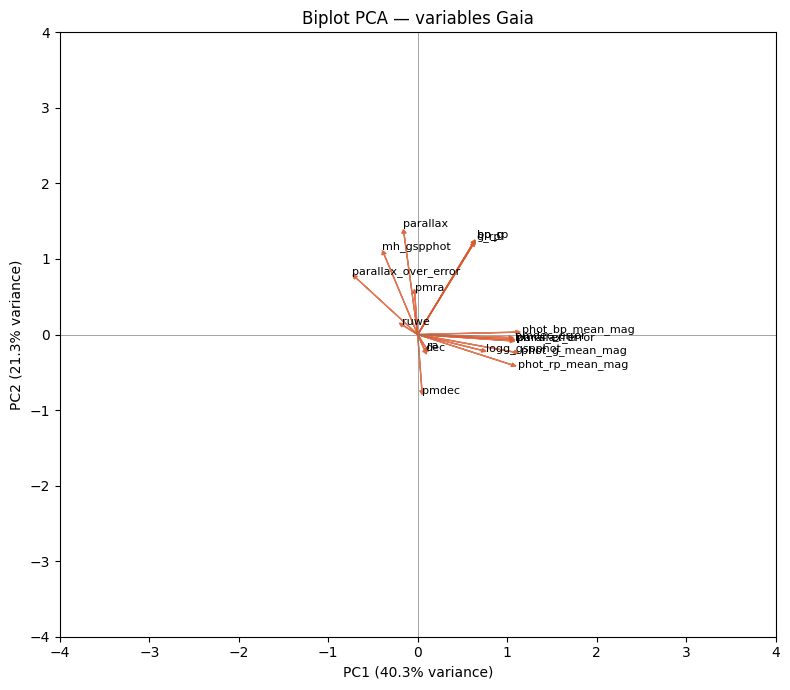

In [32]:
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=pca_cols,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
).round(3)
display(loadings)
#Biplot PC1 vs PC2
fig, ax = plt.subplots(figsize=(8, 7))

for i, var in enumerate(pca_cols):
    ax.arrow(0, 0,
             pca.components_[0, i] * 3,
             pca.components_[1, i] * 3,
             head_width=0.05, head_length=0.05,
             fc='#d85a30', ec='#d85a30', alpha=0.8)
    ax.text(pca.components_[0, i] * 3.2,
            pca.components_[1, i] * 3.2,
            var, fontsize=8)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)')
ax.set_title('Biplot PCA — variables Gaia')
plt.tight_layout()
plt.show()

Biplot Interpretation: PC1 vs PC2

The biplot displays the projection of the 18 variables onto the first two principal components, which together account for 61% of the total variance. Each arrow represents one variable: its direction indicates how it contributes to PC1 and PC2, and its length reflects the strength of that contribution — longer arrows are better represented in this two-dimensional space.

The photometric and error cluster (right, PC1 axis)
The most striking feature of the biplot is the tight bundle of arrows pointing horizontally to the right. This group includes the three magnitudes (G, BP, RP) and the three astrometric error terms (parallax error, pmra error, pmdec error), all nearly parallel to the PC1 axis. Their alignment confirms that these six variables are strongly correlated with one another and carry essentially the same information: stars that are faint are also poorly measured. The near-perfect overlap of the three magnitude arrows further illustrates the redundancy already identified in the univariate analysis.

The distance and colour cluster (upper left, PC2 axis)
A second group of arrows points upward and to the left, dominated by parallax, the three colour indices (BP-RP, BP-G, G-RP), and metallicity (mh_gspphot). These variables load positively on PC2 and negatively or weakly on PC1, meaning they carry information that is largely orthogonal to brightness. The three colour indices are almost perfectly superimposed, which is expected given that BP-RP = BP-G + G-RP by construction — they are linearly dependent and only one needs to be retained in any multivariate model.

Proper motion in declination (bottom, negative PC2)
The arrow for pmdec points downward, nearly opposite to the parallax-colour cluster. This orthogonality is physically meaningful: the motion of a star across the sky in declination is independent of how bright, red, or close it is. pmra, by contrast, has a short upward arrow, suggesting it carries a weak positive correlation with the distance-colour axis — possibly a kinematic signature of nearby red stars having higher tangential velocities on average.

Variables poorly represented in this plane
Several arrows are notably short: ra, dec, and ruwe. This does not mean these variables are unimportant — it means their variance is captured by other components not shown here. As established earlier, sky position dominates PC3 and RUWE defines PC4 almost entirely. Their short arrows in the PC1-PC2 plane are therefore expected and confirm the orthogonality of the component structure.

Overall, the biplot clearly reveals three independent dimensions in the Gaia data: a brightness-quality axis (PC1), a distance-colour axis (PC2), and by inference a sky-position axis and an astrometric-quality axis captured in higher components. This structure strongly supports reducing the 18 original variables to 4 or 5 principal components for any subsequent analysis.